In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("Train.csv")

print("Dataset Size:", data.shape)
data.head()

Dataset Size: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
np.random.seed(10)

data["Order_Hour"] = np.random.choice(range(24), size=len(data))

data[["Order_Hour"]].head()

,Order_Hour
0,9
1,4
2,15
3,0
4,17


In [4]:
data["Hour_rad"] = (data["Order_Hour"] / 24) * (2 * np.pi)

data[["Order_Hour","Hour_rad"]].head()

,Order_Hour,Hour_rad
0,9,2.356194
1,4,1.047198
2,15,3.926991
3,0,0.000000
4,17,4.450590


In [5]:
data["hour_sin_component"] = np.sin(data["Hour_rad"])
data["hour_cos_component"] = np.cos(data["Hour_rad"])

data[["Order_Hour","hour_sin_component","hour_cos_component"]].head()

,Order_Hour,hour_sin_component,hour_cos_component
0,9,0.707107,-0.707107
1,4,0.866025,0.500000
2,15,-0.707107,-0.707107
3,0,0.000000,1.000000
4,17,-0.965926,-0.258819


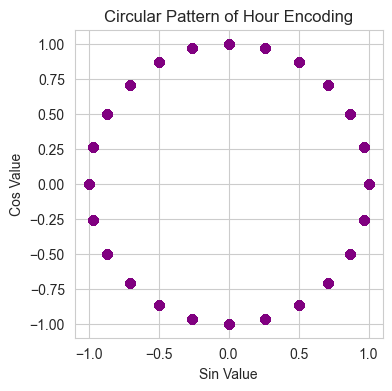

In [6]:
plt.figure(figsize=(6,4))

plt.scatter(data["hour_sin_component"], data["hour_cos_component"], color="purple", alpha=0.4)

plt.title("Circular Pattern of Hour Encoding")
plt.xlabel("Sin Value")
plt.ylabel("Cos Value")

plt.gca().set_aspect("equal")

plt.show()

In [7]:
cost_values = data["Cost_of_the_Product"]

bin_edges = np.linspace(cost_values.min(), cost_values.max(), 5)

data["Cost_Bin_Numpy"] = np.digitize(cost_values, bin_edges)

data[["Cost_of_the_Product","Cost_Bin_Numpy"]].head()

,Cost_of_the_Product,Cost_Bin_Numpy
0,177,2
1,216,3
2,183,2
3,176,2
4,184,2


In [8]:
quantile_edges = np.quantile(cost_values, [0,0.25,0.5,0.75,1])

data["Cost_Bin_Quantile"] = np.digitize(cost_values, quantile_edges)

data[["Cost_of_the_Product","Cost_Bin_Quantile"]].head()

,Cost_of_the_Product,Cost_Bin_Quantile
0,177,2
1,216,3
2,183,2
3,176,2
4,184,2


In [9]:
kb_model = KBinsDiscretizer(
    n_bins=4,
    encode="onehot",
    strategy="quantile"
)

cost_matrix = data[["Cost_of_the_Product"]]

kb_transformed = kb_model.fit_transform(cost_matrix)

In [10]:
kb_array = kb_transformed.toarray()

print("First 5 KBins Encoded Rows:")
print(kb_array[:5])

First 5 KBins Encoded Rows:
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


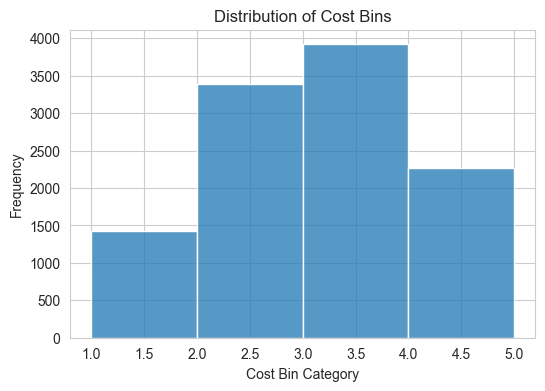

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(data["Cost_Bin_Numpy"], bins=4)

plt.title("Distribution of Cost Bins")
plt.xlabel("Cost Bin Category")
plt.ylabel("Frequency")

plt.show()